# Lab 3: Clustering Analysis Using K-Means and K-Medoids Algorithms

**Name:** Pawan Sharma  
**Course:** MSCS 634 – Advanced Big Data and Data Mining  
**Assignment:** Lab 3 – Clustering Analysis Using K-Means and K-Medoids

## Step 1: Load and Prepare the Dataset
Here, I am going to load the Wine data set from scikit-learn, inspect the features and the distribution of the classes, and normalize it using z-score normalization.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, adjusted_rand_score, pairwise_distances

RANDOM_STATE = 42
sns.set_style("whitegrid")

In [2]:
wine = load_wine()
X = pd.DataFrame(wine.data, columns=wine.feature_names)
y = pd.Series(wine.target, name="class")

print("Shape:", X.shape)
print("Classes:", list(wine.target_names))
X.head()

Shape: (178, 13)
Classes: [np.str_('class_0'), np.str_('class_1'), np.str_('class_2')]


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


In [3]:
# Feature details: data types and missing values
X.info()
print("\nMissing values in total:", X.isnull().sum().sum())

<class 'pandas.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
dtypes: float64(13)
m

In [4]:
# Summary statistics - notice how different the scales are (e.g. proline vs hue)
X.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
alcohol,178.0,13.00,0.81,11.03,12.36,13.05,13.68,14.83
malic_acid,178.0,2.34,1.12,0.74,1.60,1.87,3.08,5.80
ash,178.0,2.37,0.27,1.36,2.21,2.36,2.56,3.23
alcalinity_of_ash,178.0,19.49,3.34,10.60,17.20,19.50,21.50,30.00
magnesium,178.0,99.74,14.28,70.00,88.00,98.00,107.00,162.00
total_phenols,178.0,2.30,0.63,0.98,1.74,2.36,2.80,3.88
flavanoids,178.0,2.03,1.00,0.34,1.20,2.13,2.88,5.08
nonflavanoid_phenols,178.0,0.36,0.12,0.13,0.27,0.34,0.44,0.66
proanthocyanins,178.0,1.59,0.57,0.41,1.25,1.56,1.95,3.58
color_intensity,178.0,5.06,2.32,1.28,3.22,4.69,6.20,13.00


class
class_0    59
class_1    71
class_2    48
Name: count, dtype: int64


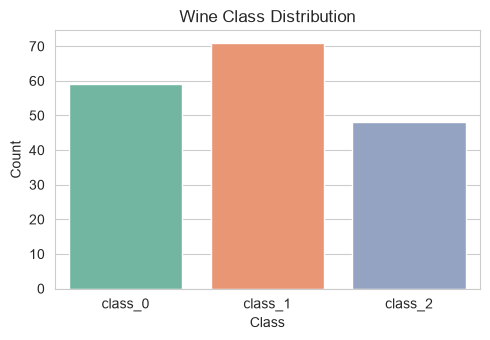

In [5]:
# Class distribution
print(y.value_counts().sort_index().rename(index=dict(enumerate(wine.target_names))))

plt.figure(figsize=(5, 3.5))
sns.countplot(x=y.map(dict(enumerate(wine.target_names))), palette="Set2", hue=y.map(dict(enumerate(wine.target_names))), legend=False)
plt.title("Wine Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

The dataset has 178 samples, 13 numeric features, and no missing values. The three classes are a bit imbalanced (59 / 71 / 48) but not badly. The feature ranges are very different - `proline` goes into the hundreds and thousands while `hue` stays around 1 - so scaling is necessary before any distance-based clustering.

In [6]:
# Z-score normalization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Mean after scaling (rounded):", np.round(X_scaled.mean(axis=0), 2))
print("Std after scaling (rounded): ", np.round(X_scaled.std(axis=0), 2))

Mean after scaling (rounded): [-0. -0. -0. -0. -0.  0. -0.  0. -0.  0.  0.  0. -0.]
Std after scaling (rounded):  [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


## Step 2: Implement K-Means Clustering
K-Means with k = 3 because the data set has 3 distinct classes. I use `n_init=10` to ensure that the algorithm starts multiple times and chooses the best one.

In [7]:
kmeans = KMeans(n_clusters=3, n_init=10, random_state=RANDOM_STATE)
kmeans_labels = kmeans.fit_predict(X_scaled)

kmeans_sil = silhouette_score(X_scaled, kmeans_labels)
kmeans_ari = adjusted_rand_score(y, kmeans_labels)

print(f"K-Means Silhouette Score: {kmeans_sil:.4f}")
print(f"K-Means Adjusted Rand Index: {kmeans_ari:.4f}")
print("Cluster sizes:", np.bincount(kmeans_labels))

K-Means Silhouette Score: 0.2849
K-Means Adjusted Rand Index: 0.8975
Cluster sizes: [65 51 62]


In [8]:
# How the clusters line up with the real classes
pd.crosstab(y.map(dict(enumerate(wine.target_names))), kmeans_labels,
            rownames=["True class"], colnames=["K-Means cluster"])

K-Means cluster,0,1,2
True class,,,
class_0,0,0,59
class_1,65,3,3
class_2,0,48,0


## Step 3: Implement K-Medoids Clustering
The standard library used is `scikit-learn-extra`, which is no longer supported and will not work with NumPy 2.x. In order to make this notebook work with my new Python installation, I have created my own K-Medoids class. It starts with k-medoids++ initialization, followed by iterations that alternate between assigning each data point to its closest medoid and choosing a data point within each cluster that has the minimum distance to the rest of the points in the cluster.

In [9]:
class KMedoids:
    """Simple K-Medoids (alternating / Voronoi-iteration variant)."""

    def __init__(self, n_clusters=3, metric="euclidean", max_iter=300, n_init=10, random_state=None):
        self.n_clusters = n_clusters
        self.metric = metric
        self.max_iter = max_iter
        self.n_init = n_init
        self.random_state = random_state

    def _init_medoids(self, D, rng):
        # k-medoids++ seeding: spread the starting medoids apart
        n = D.shape[0]
        medoids = [rng.integers(n)]
        for _ in range(1, self.n_clusters):
            dist_to_nearest = D[:, medoids].min(axis=1)
            probs = dist_to_nearest ** 2
            probs /= probs.sum()
            medoids.append(rng.choice(n, p=probs))
        return np.array(medoids)

    def _run_once(self, D, rng):
        medoids = self._init_medoids(D, rng)
        for _ in range(self.max_iter):
            labels = np.argmin(D[:, medoids], axis=1)
            new_medoids = medoids.copy()
            for k in range(self.n_clusters):
                members = np.where(labels == k)[0]
                if len(members) == 0:
                    continue
                within = D[np.ix_(members, members)].sum(axis=1)
                new_medoids[k] = members[np.argmin(within)]
            if np.array_equal(np.sort(new_medoids), np.sort(medoids)):
                break
            medoids = new_medoids
        labels = np.argmin(D[:, medoids], axis=1)
        cost = D[np.arange(D.shape[0]), medoids[labels]].sum()
        return medoids, labels, cost

    def fit(self, X):
        D = pairwise_distances(X, metric=self.metric)
        rng = np.random.default_rng(self.random_state)
        best = None
        for _ in range(self.n_init):
            result = self._run_once(D, rng)
            if best is None or result[2] < best[2]:
                best = result
        self.medoid_indices_, self.labels_, self.inertia_ = best
        self.cluster_centers_ = X[self.medoid_indices_]
        return self

    def fit_predict(self, X):
        return self.fit(X).labels_

In [10]:
kmedoids = KMedoids(n_clusters=3, metric="euclidean", n_init=10, random_state=RANDOM_STATE)
kmedoids_labels = kmedoids.fit_predict(X_scaled)

kmedoids_sil = silhouette_score(X_scaled, kmedoids_labels)
kmedoids_ari = adjusted_rand_score(y, kmedoids_labels)

print(f"K-Medoids Silhouette Score: {kmedoids_sil:.4f}")
print(f"K-Medoids Adjusted Rand Index: {kmedoids_ari:.4f}")
print("Cluster sizes:", np.bincount(kmedoids_labels))
print("Medoid sample indices:", kmedoids.medoid_indices_)

K-Medoids Silhouette Score: 0.2676
K-Medoids Adjusted Rand Index: 0.7411
Cluster sizes: [74 55 49]
Medoid sample indices: [ 35 106 148]


In [11]:
pd.crosstab(y.map(dict(enumerate(wine.target_names))), kmedoids_labels,
            rownames=["True class"], colnames=["K-Medoids cluster"])

K-Medoids cluster,0,1,2
True class,,,
class_0,59,0,0
class_1,15,55,1
class_2,0,0,48


## Step 4: Visualize and Compare Results
The number of dimensions in the dataset is 13; therefore, PCA projection onto two dimensions is used exclusively for visualization purposes. Clustering has been carried out on all 13 features of the dataset after scaling. The centroids of K-Means and the medoids of K-Medoids have been projected using PCA.

Variance explained by PC1 + PC2: 55.41 %


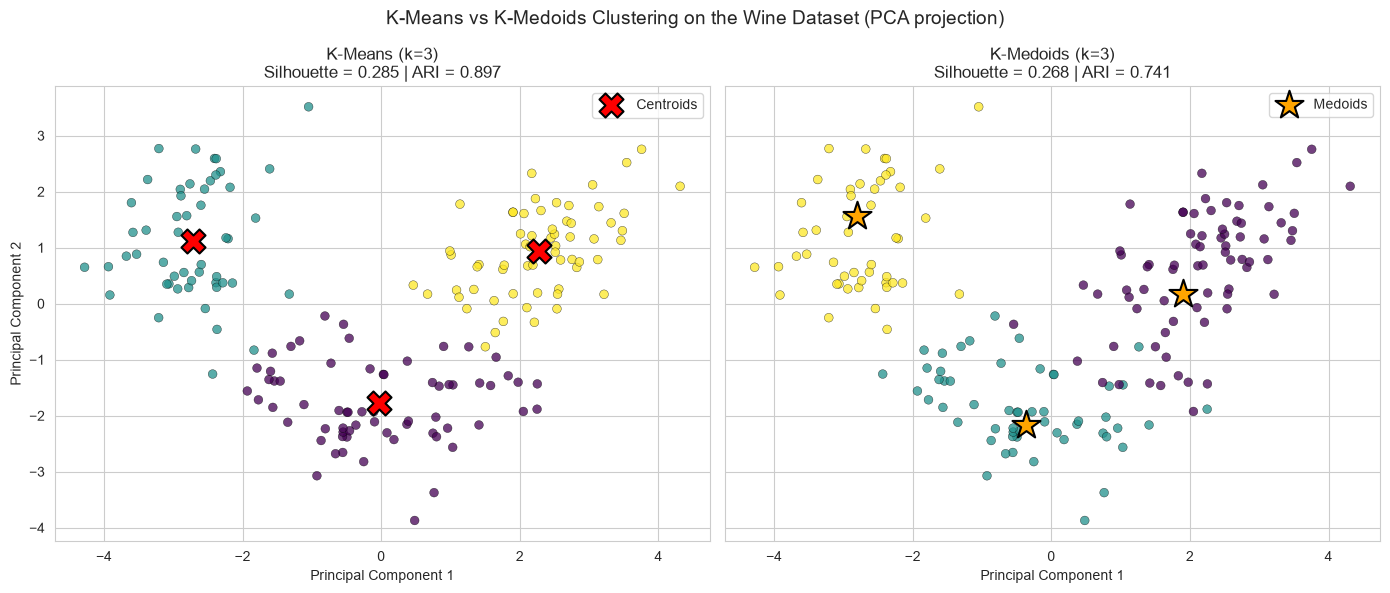

In [12]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)
print("Variance explained by PC1 + PC2:", round(pca.explained_variance_ratio_.sum() * 100, 2), "%")

centroids_pca = pca.transform(kmeans.cluster_centers_)
medoids_pca = pca.transform(kmedoids.cluster_centers_)

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels, cmap="viridis", s=40, alpha=0.75, edgecolor="k", linewidth=0.3)
axes[0].scatter(centroids_pca[:, 0], centroids_pca[:, 1], c="red", marker="X", s=300, edgecolor="black", linewidth=1.5, label="Centroids")
axes[0].set_title(f"K-Means (k=3)\nSilhouette = {kmeans_sil:.3f} | ARI = {kmeans_ari:.3f}")
axes[0].set_xlabel("Principal Component 1")
axes[0].set_ylabel("Principal Component 2")
axes[0].legend()

axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=kmedoids_labels, cmap="viridis", s=40, alpha=0.75, edgecolor="k", linewidth=0.3)
axes[1].scatter(medoids_pca[:, 0], medoids_pca[:, 1], c="orange", marker="*", s=450, edgecolor="black", linewidth=1.5, label="Medoids")
axes[1].set_title(f"K-Medoids (k=3)\nSilhouette = {kmedoids_sil:.3f} | ARI = {kmedoids_ari:.3f}")
axes[1].set_xlabel("Principal Component 1")
axes[1].legend()

plt.suptitle("K-Means vs K-Medoids Clustering on the Wine Dataset (PCA projection)", fontsize=14)
plt.tight_layout()
plt.show()

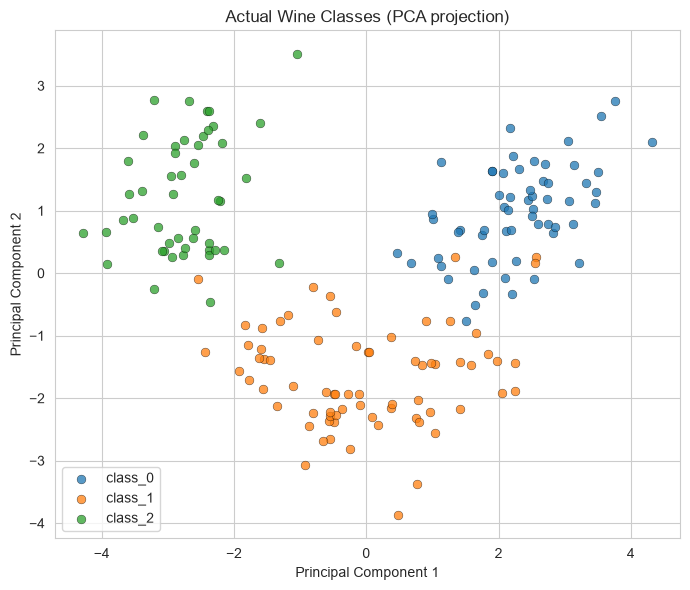

In [13]:
# True classes for reference
plt.figure(figsize=(7, 6))
for cls, name in enumerate(wine.target_names):
    mask = y == cls
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], s=40, alpha=0.75, edgecolor="k", linewidth=0.3, label=name)
plt.title("Actual Wine Classes (PCA projection)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.tight_layout()
plt.show()

In [14]:
comparison = pd.DataFrame({
    "Algorithm": ["K-Means", "K-Medoids"],
    "Silhouette Score": [kmeans_sil, kmedoids_sil],
    "Adjusted Rand Index": [kmeans_ari, kmedoids_ari],
    "Cluster Sizes": [np.bincount(kmeans_labels).tolist(), np.bincount(kmedoids_labels).tolist()],
}).round(4)
comparison

,Algorithm,Silhouette Score,Adjusted Rand Index,Cluster Sizes
0,K-Means,0.2849,0.8975,"[65, 51, 62]"
1,K-Medoids,0.2676,0.7411,"[74, 55, 49]"


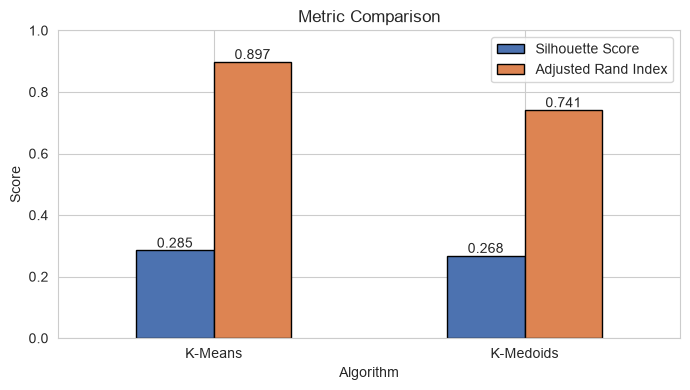

In [15]:
fig, ax = plt.subplots(figsize=(7, 4))
comparison.set_index("Algorithm")[["Silhouette Score", "Adjusted Rand Index"]].plot(kind="bar", ax=ax, color=["#4C72B0", "#DD8452"], edgecolor="black")
ax.set_title("Metric Comparison")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
ax.tick_params(axis="x", rotation=0)
for c in ax.containers:
    ax.bar_label(c, fmt="%.3f")
plt.tight_layout()
plt.show()

### Analysis and Comparison
| Metric | K-Means | K-Medoids |
|---|---|---|
| Silhouette Score | 0.2849 | 0.2676 |
| Adjusted Rand Index | 0.8975 | 0.7411 |
| Cluster sizes | 65 / 51 / 62 | 74 / 55 / 49 |

**Which algorithm produced better-defined clusters?**  
K-Means outperformed K-Medoids in both measures. K-Means has a slightly higher silhouette score (0.285) than K-Medoids (0.268). This indicates that K-Means clusters have more compactness and better separation than K-Medoids. More notably, the difference between the Adjusted Rand Index values is significant – 0.897 for K-Means and 0.741 for K-Medoids. As per the crosstab results, K-Means assigned six wines out of the total of 178 to wrong classes (from class_1) whereas K-Medoids classified 15 wines from class_1 in class_0. Both the silhouette scores are relatively low due to overlapping of classes in 13 dimensions.

**What differences do I see in cluster shapes or positioning?**  
K-Means centroid positions themselves right in the center of their respective clusters since they are averages. K-Medoids, however, cannot use non-existent objects like centroids to represent clusters, which is why they appear near the centers but not directly in the middle. The most noticeable difference can be observed at the border between class_0 and class_1 (bottom-middle to the right in the picture). K-Medoids has shifted the position of the medoid for the class_0 cluster closer to the center and expanded it to 74 objects by merging part of the class_1 cluster. K-Means has positioned the border closer to the actual one.

**When would I pick K-Means vs K-Medoids?**  
K-Means is appropriate for the data set that is numeric and scaled, has approximately spherical clusters and contains few outliers, like our standardized Wine data set. Furthermore, K-Means is faster, because it does not require calculation of a pairwise distance matrix. The appropriate method for the data sets that contain outliers or noise is K-Medoids, as the outliers will not influence the medoid in the same way as they do the mean value. Furthermore, K-Medoids can be used for creating a real representative samples for the clusters (for example, "average" customer/wine), or for using another distance than Euclidean, e.g., Manhattan or user-defined dissimilarity measure for categorical data. However, the disadvantage of K-Medoids is its slower performance on large data sets, due to the necessity to calculate n × n distance matrix. In case of our lab assignment, K-Means seemed more appropriate.